# RMSD analysis checks

This notebook exercises the new RMSD analysis helpers in `ensemblelab.analysis.rmsd`.
It verifies the matrix/heatmap API against a generated ensemble and confirms that
conformer-level molecule access works from the public object model.

RMSD analysis check passed
[0, 1]
[[0.         0.44682459]
 [0.44682459 0.        ]]


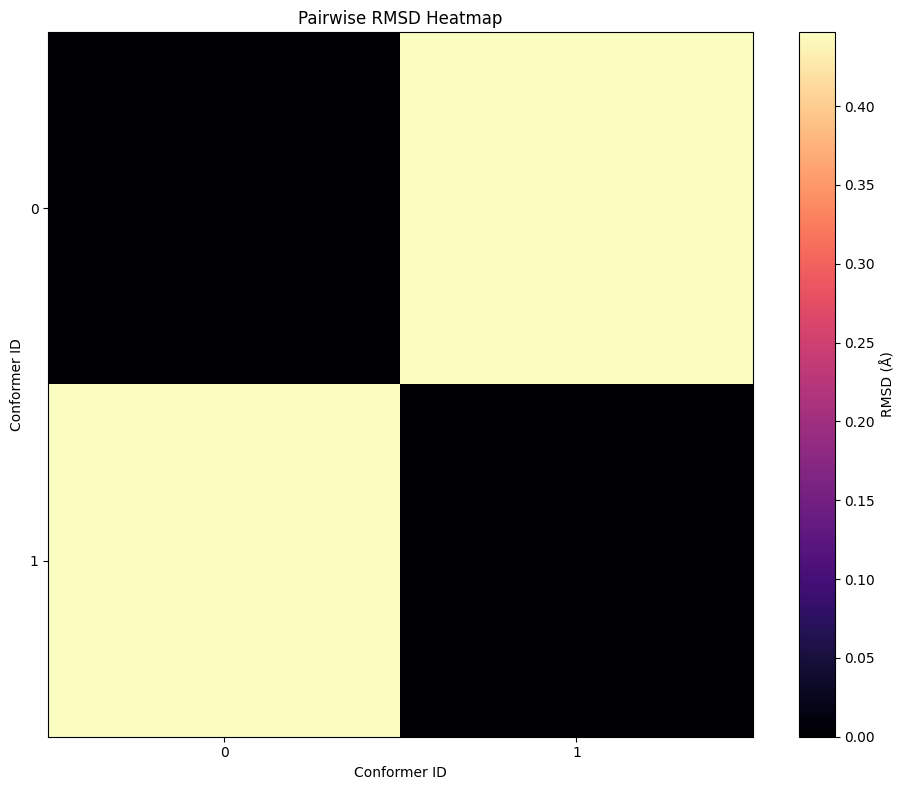

In [1]:
from pathlib import Path
import importlib
import sys

project_root = Path.cwd().resolve()
while project_root != project_root.parent and not (project_root / 'src').is_dir():
    project_root = project_root.parent
if not (project_root / 'src' / 'ensemblelab').is_dir():
    raise RuntimeError('Open this notebook from within the ensemblelab repository.')
sys.path.insert(0, str(project_root / 'src'))

import ensemblelab.analysis.rmsd as rmsd_mod
importlib.reload(rmsd_mod)

from ensemblelab.generators import generate
from ensemblelab.analysis.rmsd import rmsd, rmsd_matrix, rmsd_heatmap

ensemble = generate('CCO', n_confs=2)
matrix, ids = rmsd_matrix(ensemble)
assert matrix.shape == (2, 2)
assert tuple(ids) == ensemble.conformer_ids
assert matrix.shape[0] == len(ensemble.conformers)
assert matrix[0, 0] == 0.0
assert matrix[0, 1] == matrix[1, 0]
assert matrix[1, 1] == 0.0

first = ensemble.conformers[0]
second = ensemble.conformers[1]
assert rmsd(first, second, ensemble.molecule) >= 0.0

heatmap_matrix, axes = rmsd_heatmap(ensemble, show=False)
assert heatmap_matrix.shape == matrix.shape
assert heatmap_matrix.shape == (len(ensemble.conformers), len(ensemble.conformers))

print('RMSD analysis check passed')
print(ids)
print(matrix)
